In [29]:
#####   Load dataset   #########
#This dataset represents historical production/demand.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
'Year':[2018,2019,2020,2021,2022,2023,2024,2025],
'Sugar_MT':[420000,435000,450000,470000,480000,500000,510000,520000],
'Ethanol_ML':[120,135,150,190,240,290,330,360],
'Power_MW':[150,155,160,165,168,170,172,175]
}

df = pd.DataFrame(data)                           #data stored in a variable called 'df'- Dataframe
print(df)

print(f"------------------------------------")
df.head(9)          

   Year  Sugar_MT  Ethanol_ML  Power_MW
0  2018    420000         120       150
1  2019    435000         135       155
2  2020    450000         150       160
3  2021    470000         190       165
4  2022    480000         240       168
5  2023    500000         290       170
6  2024    510000         330       172
7  2025    520000         360       175
------------------------------------


,Year,Sugar_MT,Ethanol_ML,Power_MW
0,2018,420000,120,150
1,2019,435000,135,155
2,2020,450000,150,160
3,2021,470000,190,165
4,2022,480000,240,168
5,2023,500000,290,170
6,2024,510000,330,172
7,2025,520000,360,175


In [12]:
####  Demand Growth Analysis  #####

#I used the pct_change() function in Pandas to calculate the year-over-year percentage growth for each product.

df = df.set_index('Year')      

growth = df[['Sugar_MT','Ethanol_ML','Power_MW']].pct_change()*100                               # annual growth rate
growth = growth.dropna().round(3)                                                                # remove the first meaningless row
print(growth)


      Sugar_MT  Ethanol_ML  Power_MW
Year                                
2019     3.571      12.500     3.333
2020     3.448      11.111     3.226
2021     4.444      26.667     3.125
2022     2.128      26.316     1.818
2023     4.167      20.833     1.190
2024     2.000      13.793     1.176
2025     1.961       9.091     1.744


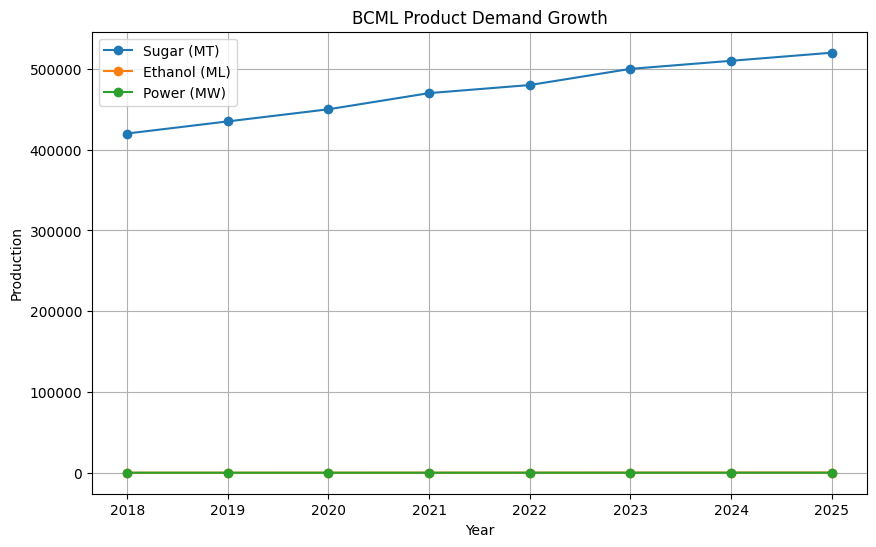

In [16]:
####  Plot Demand Trends  ######

plt.figure(figsize=(10,6))

plt.plot(df['Year'], df['Sugar_MT'], marker='o', label='Sugar (MT)')
plt.plot(df['Year'], df['Ethanol_ML'], marker='o', label='Ethanol (ML)')
plt.plot(df['Year'], df['Power_MW'], marker='o', label='Power (MW)')

plt.title("BCML Product Demand Growth")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.legend()
plt.show()

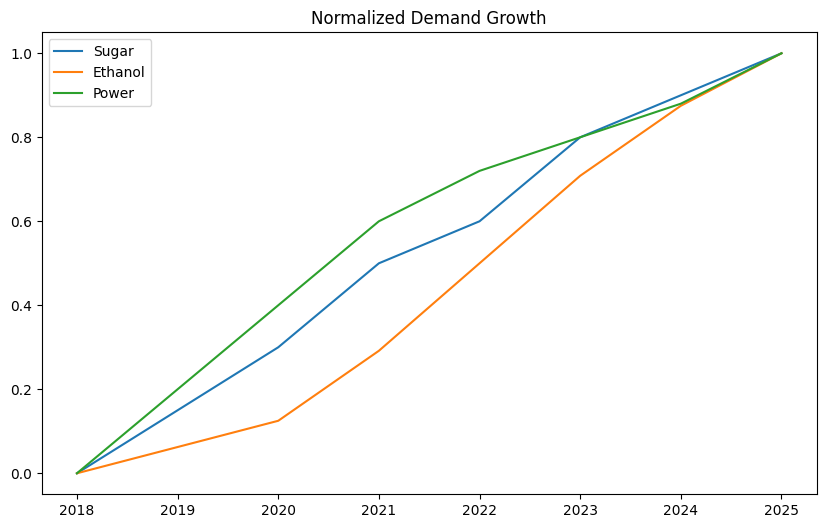

In [17]:


normalized = (df - df.min()) / (df.max() - df.min())

plt.figure(figsize=(10,6))
plt.plot(df['Year'], normalized['Sugar_MT'], label='Sugar')
plt.plot(df['Year'], normalized['Ethanol_ML'], label='Ethanol')
plt.plot(df['Year'], normalized['Power_MW'], label='Power')

plt.legend()
plt.title("Normalized Demand Growth")
plt.show()

In [20]:

######  Revenue Estimation    ########

sugar_price = 38000   # per ton
ethanol_price = 65000 # per KL
power_price = 5000000 # per MW/year approx

df['Sugar_Revenue'] = df['Sugar_MT'] * sugar_price
df['Ethanol_Revenue'] = df['Ethanol_ML'] * ethanol_price
df['Power_Revenue'] = df['Power_MW'] * power_price

df['Total_Revenue'] = df['Sugar_Revenue'] + df['Ethanol_Revenue'] + df['Power_Revenue']

# Convert to Crores

df['Total_Revenue_Cr'] = df['Total_Revenue'] / 10000000

print(df[['Year','Total_Revenue_Cr']].round(2))

   Year  Total_Revenue_Cr
0  2018           1671.78
1  2019           1731.38
2  2020           1790.98
3  2021           1869.74
4  2022           1909.56
5  2023           1986.88
6  2024           2026.14
7  2025           2065.84


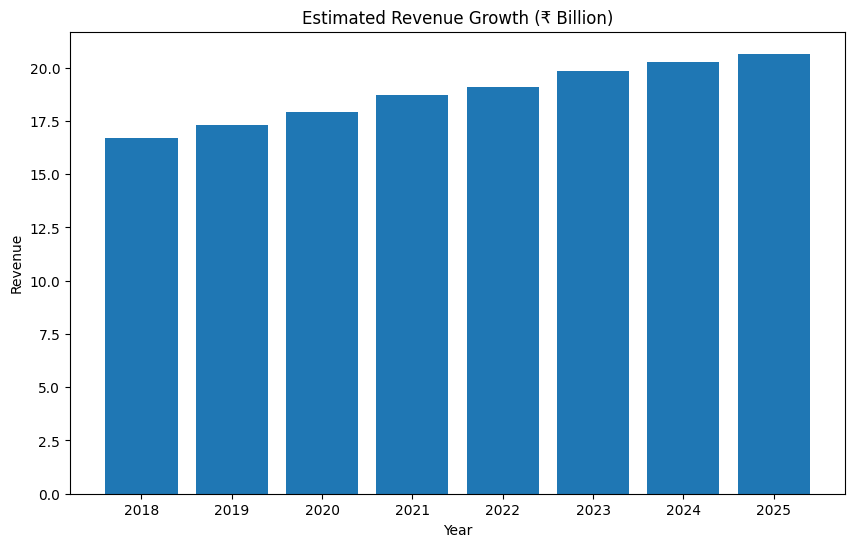

In [21]:
#####  Revenue Visualization  ########

plt.figure(figsize=(10,6))
plt.bar(df['Year'], df['Total_Revenue']/1e9)
plt.title("Estimated Revenue Growth (₹ Billion)")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

In [22]:
####   Demand Forecast (Simple Projection)  ####

future_years = [2026,2027,2028,2029,2030]

sugar_forecast = np.linspace(530000,580000,5)
ethanol_forecast = np.linspace(400,600,5)
pla_forecast = [20000,35000,50000,65000,75000]

forecast = pd.DataFrame({
'Year':future_years,
'Sugar_MT':sugar_forecast,
'Ethanol_ML':ethanol_forecast,
'PLA_MT':pla_forecast
})

print(forecast)


   Year  Sugar_MT  Ethanol_ML  PLA_MT
0  2026  530000.0       400.0   20000
1  2027  542500.0       450.0   35000
2  2028  555000.0       500.0   50000
3  2029  567500.0       550.0   65000
4  2030  580000.0       600.0   75000


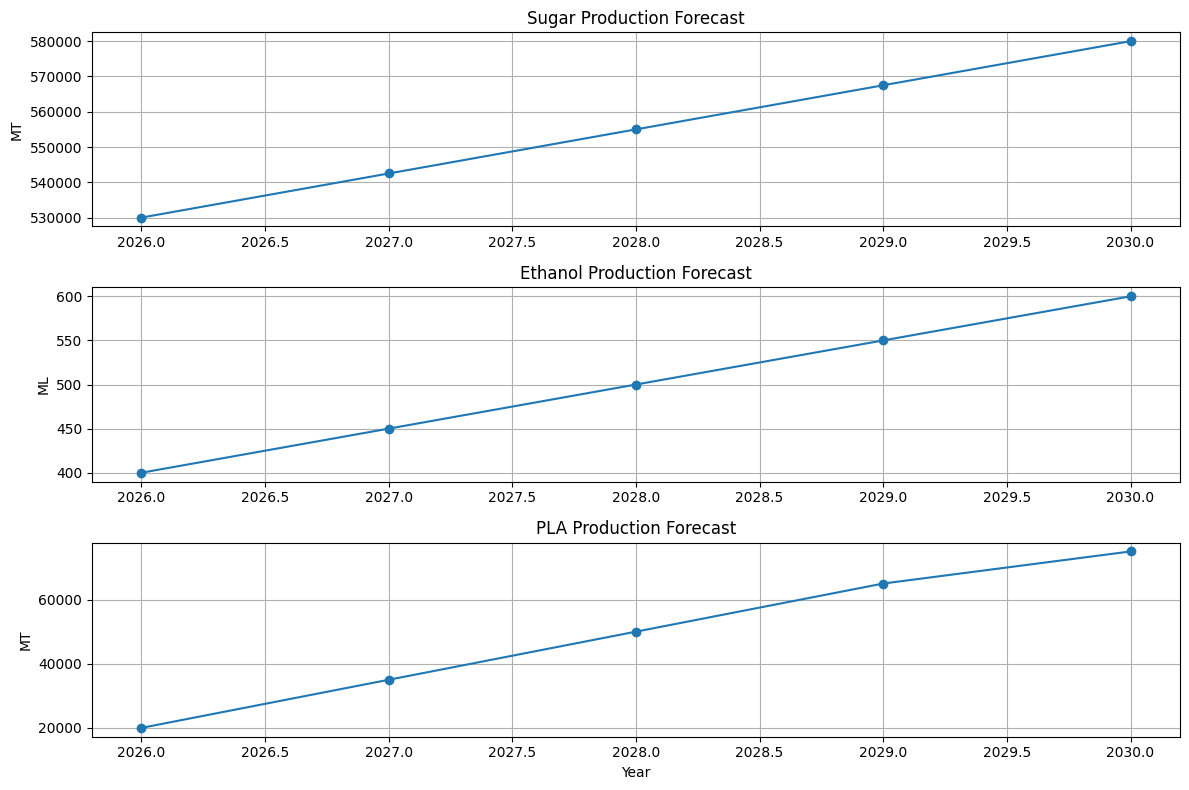

In [23]:

### Visualisation separately each forcast ###

plt.figure(figsize=(12,8))

# Sugar forecast
plt.subplot(3,1,1)
plt.plot(forecast['Year'], forecast['Sugar_MT'], marker='o')
plt.title("Sugar Production Forecast")
plt.ylabel("MT")
plt.grid(True)

# Ethanol forecast
plt.subplot(3,1,2)
plt.plot(forecast['Year'], forecast['Ethanol_ML'], marker='o')
plt.title("Ethanol Production Forecast")
plt.ylabel("ML")
plt.grid(True)

# PLA forecast
plt.subplot(3,1,3)
plt.plot(forecast['Year'], forecast['PLA_MT'], marker='o')
plt.title("PLA Production Forecast")
plt.xlabel("Year")
plt.ylabel("MT")
plt.grid(True)

plt.tight_layout()
plt.show()


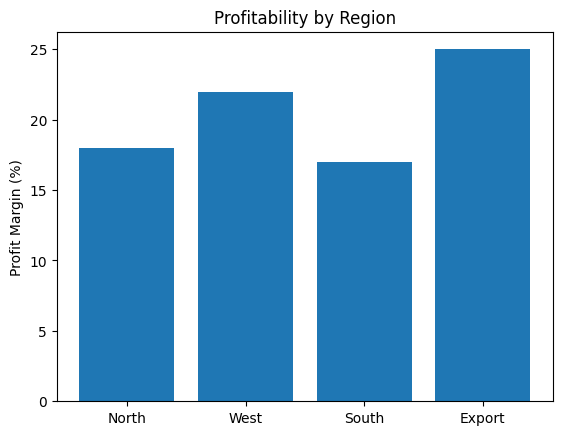

In [25]:
import matplotlib.pyplot as plt

regions = ['North','West','South','Export']
profit_margin = [0.18,0.22,0.17,0.25]

profit_percent = [p*100 for p in profit_margin]

plt.bar(regions, profit_percent)

plt.title("Profitability by Region")
plt.ylabel("Profit Margin (%)")

plt.show()

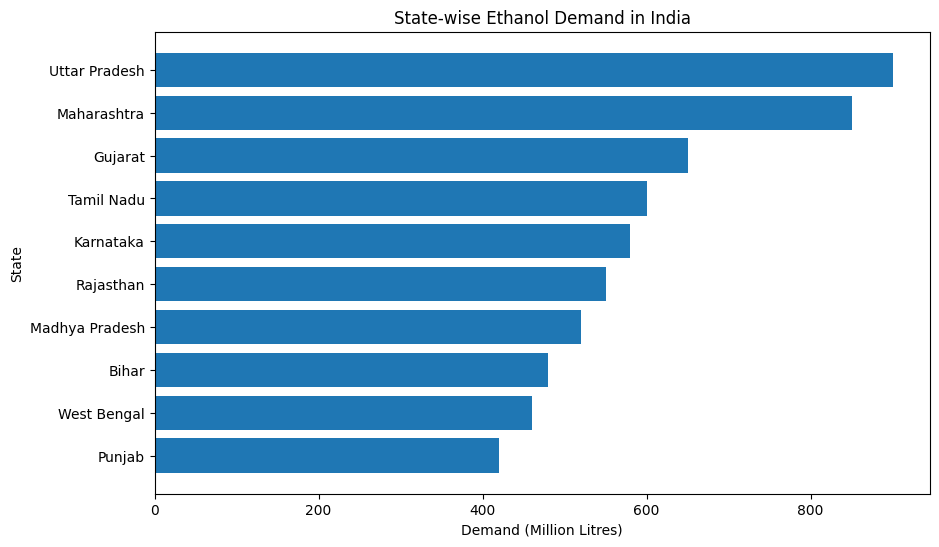

In [26]:
###   State-Wise Ethanol Demand Heatmap (India)  ####

data = {
'State':['Uttar Pradesh','Maharashtra','Gujarat','Tamil Nadu','Karnataka',
'Rajasthan','Madhya Pradesh','Bihar','West Bengal','Punjab'],

'Ethanol_Demand_ML':[900,850,650,600,580,550,520,480,460,420]
}

df = pd.DataFrame(data)

df = df.sort_values('Ethanol_Demand_ML')

plt.figure(figsize=(10,6))

plt.barh(df['State'], df['Ethanol_Demand_ML'])

plt.title("State-wise Ethanol Demand in India")
plt.xlabel("Demand (Million Litres)")
plt.ylabel("State")

plt.show()

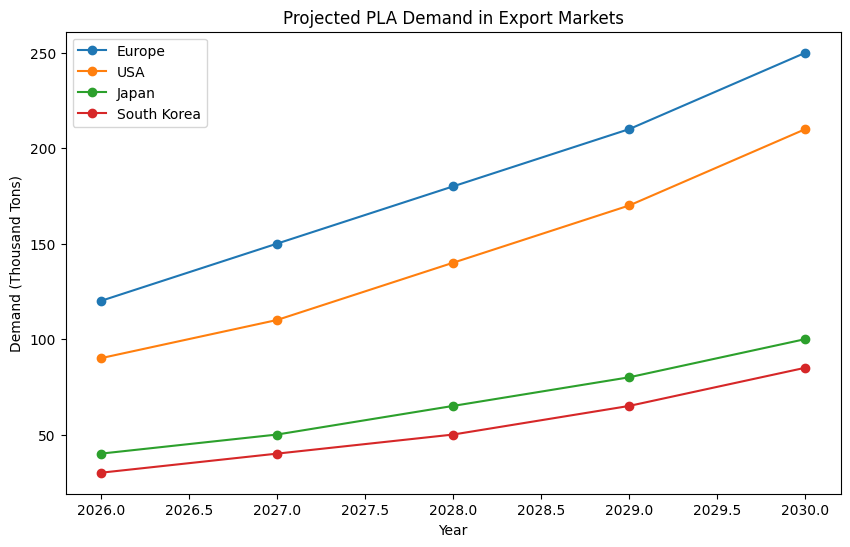

In [27]:
#####   PLA Demand Projection for Export Markets   ###

data = {
'Year':[2026,2027,2028,2029,2030],
'EU':[120,150,180,210,250],
'USA':[90,110,140,170,210],
'Japan':[40,50,65,80,100],
'South_Korea':[30,40,50,65,85]
}

df = pd.DataFrame(data)

plt.figure(figsize=(10,6))

plt.plot(df['Year'],df['EU'],marker='o',label='Europe')
plt.plot(df['Year'],df['USA'],marker='o',label='USA')
plt.plot(df['Year'],df['Japan'],marker='o',label='Japan')
plt.plot(df['Year'],df['South_Korea'],marker='o',label='South Korea')

plt.title("Projected PLA Demand in Export Markets")
plt.xlabel("Year")
plt.ylabel("Demand (Thousand Tons)")
plt.legend()

plt.show()